# 🔀 Crime Hotspot — Hybrid Model Variants (V2 / V3 / V4) + Best-Model Comparison

**Standalone Colab notebook.** Trains three new hybrid architectures and compares all four
hybrids on Chicago (in-domain) and LA (zero-shot transfer).

## Three Variants

| Model | Spatial branch A | Spatial branch B | Temporal encoder | Key idea |
|---|---|---|---|---|
| **Hybrid V1** *(baseline)* | ConvLSTM (3×3) | STGAT (GAT ×2) | GRU | Gated fusion |
| **Hybrid V2** | ConvLSTM (3×3) | PatchSTTransformer | GRU | Global spatial context via patches instead of local graph |
| **Hybrid V3** | ConvLSTM (3×3) | STGAT (GAT ×2) | Temporal Self-Attention | Replace GRU with lightweight self-attention over T=7 steps |
| **Hybrid V4** | Multi-scale ConvLSTM (3×3 + 5×5) | STGAT (GAT ×2) | GRU | Two conv scales capture fine-grained + coarse spatial patterns simultaneously |

## Why these three?
- **V2** tests whether *global* spatial attention (transformer patches) beats *local* graph attention for crime spillover
- **V3** tests whether *direct temporal comparison* (attention over days) beats sequential GRU aggregation  
- **V4** tests whether *multi-scale local context* (two kernel sizes) better captures both block-level and neighbourhood-level patterns

## Outputs saved
```
models/hybridv2.pt  hybridv3.pt  hybridv4.pt
outputs/calibration/hybridv2/  hybridv3/  hybridv4/
outputs/hybrid_variants/
```


## 📁 STEP 1 — Mount Drive & Install Dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import subprocess
subprocess.run(['pip', 'install', '-q', 'torch_geometric'], check=True)
subprocess.run(['pip', 'install', '-q',
                'pyg_lib', 'torch_scatter', 'torch_sparse',
                '-f', 'https://data.pyg.org/whl/torch-2.1.0+cu121.html'],
               check=False)
subprocess.run(['pip', 'install', '-q', 'sympy==1.13.1'], check=True)

import os, json, math, warnings, gc
import numpy  as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression as _LR
from scipy.optimize       import minimize_scalar
from scipy.special        import expit as scipy_expit
from sklearn.calibration  import calibration_curve

BASE_DIR  = '/content/drive/MyDrive/CrimeHotspot'
PROC_DIR  = f'{BASE_DIR}/data/processed'
MODEL_DIR = f'{BASE_DIR}/models'
CAL_BASE  = f'{BASE_DIR}/outputs/calibration'
OUT_DIR   = f'{BASE_DIR}/outputs/hybrid_variants'

for d in [MODEL_DIR,
          f'{CAL_BASE}/hybridv2', f'{CAL_BASE}/hybridv3', f'{CAL_BASE}/hybridv4',
          f'{OUT_DIR}/chicago', f'{OUT_DIR}/la',
          f'{OUT_DIR}/crosscity', f'{OUT_DIR}/tables']:
    os.makedirs(d, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'Outputs : {OUT_DIR}')
print('✅ Setup complete')


Mounted at /content/drive
Device  : cuda
Outputs : /content/drive/MyDrive/CrimeHotspot/outputs/hybrid_variants
✅ Setup complete


## 📂 STEP 2 — Load Config, Data & Splits

In [3]:
with open(f'{PROC_DIR}/config.json') as f:
    cfg = json.load(f)

CELL_SIZE            = cfg['CELL_SIZE']
LAT_MIN, LAT_MAX     = cfg['LAT_MIN'], cfg['LAT_MAX']
LON_MIN, LON_MAX     = cfg['LON_MIN'], cfg['LON_MAX']
GRID_ROWS, GRID_COLS = cfg['GRID_ROWS'], cfg['GRID_COLS']
SEQ_LEN              = cfg['SEQ_LEN']

daily       = pd.read_csv(f'{PROC_DIR}/daily_features.csv', parse_dates=['date_day'])
cell_index  = pd.read_csv(f'{PROC_DIR}/cell_index.csv')
grid_tensor = np.load(f'{PROC_DIR}/grid_tensor.npy')

_, H, W  = grid_tensor.shape
N        = H * W
T_total  = grid_tensor.shape[0]
split_t  = int(T_total * 0.80)
cal_split= int(split_t * 0.85)

# ── Static POI + KDE features ──────────────────────────────────────────────
STATIC_COLS = ['poi_bar','poi_school','poi_transit','poi_hospital','kde_density']
poi_per_cell = (daily.groupby('cell_id')[STATIC_COLS]
                      .mean()
                      .reindex(cell_index['cell_id'])
                      .fillna(0))
poi_min  = poi_per_cell.min()
poi_max  = poi_per_cell.max()
poi_norm = (poi_per_cell - poi_min) / (poi_max - poi_min + 1e-9)
node_features = poi_norm.values.astype(np.float32)   # (N, 5)
IN_CH = 1 + node_features.shape[1]                   # 6

print(f'Grid tensor   : {grid_tensor.shape}  ({H}×{W} = {N} cells)')
print(f'Train/cal/test: 0→{cal_split} / {cal_split}→{split_t} / {split_t}→{T_total}')
print(f'SEQ_LEN       : {SEQ_LEN}  |  IN_CH : {IN_CH}')
print('✅ Data loaded')


Grid tensor   : (1547, 85, 86)  (85×86 = 7310 cells)
Train/cal/test: 0→1051 / 1051→1237 / 1237→1547
SEQ_LEN       : 7  |  IN_CH : 6
✅ Data loaded


## ⚙️ STEP 3 — Shared Utilities

In [4]:
# ── Queen adjacency graph ─────────────────────────────────────────────────
def build_queen_graph(H, W):
    src, dst = [], []
    for r in range(H):
        for c in range(W):
            node = r * W + c
            for dr in [-1,0,1]:
                for dc in [-1,0,1]:
                    if dr==0 and dc==0: continue
                    nr, nc = r+dr, c+dc
                    if 0 <= nr < H and 0 <= nc < W:
                        src.append(node); dst.append(nr*W+nc)
    return torch.tensor([src, dst], dtype=torch.long)

edge_index     = build_queen_graph(H, W)
edge_index_dev = edge_index.to(DEVICE)
print(f'Graph: {N} nodes, {edge_index.shape[1]} edges')

# ── Dataset ───────────────────────────────────────────────────────────────
class CrimeGraphDataset(Dataset):
    def __init__(self, grid, seq_len, node_feats):
        self.grid = grid; self.seq_len = seq_len
        self.node_feats = node_feats
        self.N = grid.shape[1] * grid.shape[2]
    def __len__(self): return len(self.grid) - self.seq_len
    def __getitem__(self, idx):
        x_dyn  = self.grid[idx:idx+self.seq_len].astype(np.float32)
        x_dyn  = x_dyn.reshape(self.seq_len, self.N, 1)
        x_dyn /= (x_dyn.max() + 1e-9)
        static = np.tile(self.node_feats[np.newaxis], (self.seq_len, 1, 1))
        x      = np.concatenate([x_dyn, static], axis=-1)
        y      = (self.grid[idx+self.seq_len] > 0).astype(np.float32).reshape(self.N)
        return torch.tensor(x), torch.tensor(y)

train_ds = CrimeGraphDataset(grid_tensor[:split_t],           SEQ_LEN, node_features)
cal_ds   = CrimeGraphDataset(grid_tensor[cal_split:split_t],  SEQ_LEN, node_features)
test_ds  = CrimeGraphDataset(grid_tensor[split_t:],           SEQ_LEN, node_features)
train_dl = DataLoader(train_ds, batch_size=2, shuffle=True,  num_workers=2, pin_memory=True)
cal_dl   = DataLoader(cal_ds,   batch_size=2, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  batch_size=2, shuffle=False, num_workers=2)
print(f'Train/Cal/Test : {len(train_ds)} / {len(cal_ds)} / {len(test_ds)} samples')

# ── Metric helpers ────────────────────────────────────────────────────────
def compute_pai(y_true, y_proba, k):
    n_total = len(y_true); n_hs = max(float(y_true.sum()),1)
    k_ = min(k, n_total); topk = np.argsort(y_proba)[-k_:]
    return round((float(y_true[topk].sum())/n_hs)/(k_/n_total), 4)

def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    m = {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'AUROC'    : round(roc_auc_score(y_true, y_proba), 4),
        'AUPRC'    : round(average_precision_score(y_true, y_proba), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
    }
    for k in [50,100,200]: m[f'PAI@{k}'] = compute_pai(y_true, y_proba, k)
    return m

def find_temperature(logits, y_true):
    def nll(T):
        p = scipy_expit(logits / T)
        p = np.clip(p, 1e-7, 1-1e-7)
        return -np.mean(y_true*np.log(p)+(1-y_true)*np.log(1-p))
    T_opt = minimize_scalar(nll, bounds=(0.1,20.0), method='bounded').x
    return T_opt, scipy_expit(logits / T_opt)

def platt_calibrate(y_cal_proba, y_cal_true, y_test_proba):
    platt = _LR(C=1.0, solver='lbfgs', max_iter=1000)
    platt.fit(y_cal_proba.reshape(-1,1), y_cal_true)
    y_test_cal = platt.predict_proba(y_test_proba.reshape(-1,1))[:,1]
    y_cal_cal  = platt.predict_proba(y_cal_proba.reshape(-1,1))[:,1]
    prec, rec, th = precision_recall_curve(y_cal_true, y_cal_cal)
    f1s = 2*prec*rec/(prec+rec+1e-9)
    best_t = float(th[np.argmax(f1s)])
    return y_test_cal, best_t, platt

def run_inference(model, loader, edge_idx, apply_sigmoid=True):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(DEVICE), edge_idx)
            out    = torch.sigmoid(logits) if apply_sigmoid else logits
            preds.append(out.cpu().numpy()); trues.append(yb.numpy())
    return np.concatenate(preds).ravel(), np.concatenate(trues).ravel()

def save_artefacts(name, city, y_ts, y_cal, y_true, T_opt, best_t, platt):
    d = f'{CAL_BASE}/{name}'
    os.makedirs(d, exist_ok=True)
    np.save(f'{d}/{city}_proba_ts.npy',  y_ts.astype(np.float32))
    np.save(f'{d}/{city}_proba_cal.npy', y_cal.astype(np.float32))
    np.save(f'{d}/{city}_true.npy',      y_true.astype(np.int8))
    with open(f'{d}/{city}_meta.json','w') as f:
        json.dump({'T_opt': float(T_opt), 'best_threshold': float(best_t)}, f, indent=2)
    joblib.dump(platt, f'{d}/{city}_platt_scaler.pkl')

def train_and_calibrate(model, model_name, save_pt, epochs=25, lr=8e-4, alpha=0.25, epochs_p2=15):
    """Phase 1 supervised training → Phase 2 self-training → Chicago calibration."""
    flat  = (grid_tensor[:split_t] > 0).astype(np.float32).ravel()
    pos_r = flat.mean()
    pos_w = torch.tensor([min((1 - pos_r) / (pos_r + 1e-9), 8.)]).to(DEVICE)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    # ── Phase 1: standard supervised training ────────────────────────────────
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5)
    losses_p1 = []
    print(f'[{model_name}] Phase 1 — {epochs} epochs supervised...')
    for ep in range(1, epochs + 1):
        model.train(); eloss = 0.
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb, edge_index_dev), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); eloss += loss.item()
        avg = eloss / len(train_dl); losses_p1.append(avg); sch.step()
        if ep % 5 == 0:
            print(f'  P1 Epoch {ep:02d}/{epochs}  loss={avg:.4f}  lr={opt.param_groups[0]["lr"]:.2e}')

    # ── Phase 2: collect soft pseudo-labels on training set ──────────────────
    print(f'\n[{model_name}] Collecting Phase 1 pseudo-labels (α={alpha})...')
    train_ref_dl = DataLoader(train_ds, batch_size=2, shuffle=False,
                              num_workers=2, pin_memory=True)
    model.eval()
    p1_proba_list = []
    with torch.no_grad():
        for xb, _ in train_ref_dl:
            logits = model(xb.to(DEVICE), edge_index_dev)
            p1_proba_list.append(torch.sigmoid(logits).cpu().numpy())
    p1_proba_all = np.concatenate(p1_proba_list, axis=0)   # (n_train, N)
    print(f'  Pseudo-label array: {p1_proba_all.shape}  '
          f'mean={p1_proba_all.mean():.4f}  max={p1_proba_all.max():.4f}')

    # ── Self-training dataset with mixed soft targets ─────────────────────────
    class SelfTrainDataset(Dataset):
        def __init__(self, base_ds, soft_proba, alpha):
            self.base = base_ds; self.soft = soft_proba; self.alpha = alpha
        def __len__(self): return len(self.base)
        def __getitem__(self, idx):
            x, y_hard = self.base[idx]
            y_soft    = torch.tensor(self.soft[idx], dtype=torch.float32)
            y_mixed   = (1 - self.alpha) * y_hard + self.alpha * y_soft
            return x, y_mixed

    st_ds = SelfTrainDataset(train_ds, p1_proba_all, alpha=alpha)
    st_dl = DataLoader(st_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=True)

    opt2 = torch.optim.AdamW(model.parameters(), lr=lr * 0.25, weight_decay=1e-4)
    sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=epochs_p2, eta_min=1e-6)
    losses_p2 = []
    print(f'[{model_name}] Phase 2 — {epochs_p2} epochs self-training...')
    for ep in range(1, epochs_p2 + 1):
        model.train(); eloss = 0.
        for xb, yb_mixed in st_dl:
            xb, yb_mixed = xb.to(DEVICE), yb_mixed.to(DEVICE)
            opt2.zero_grad()
            loss = crit(model(xb, edge_index_dev), yb_mixed)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt2.step(); eloss += loss.item()
        avg = eloss / len(st_dl); losses_p2.append(avg); sch2.step()
        if ep % 5 == 0:
            print(f'  P2 Epoch {ep:02d}/{epochs_p2}  loss={avg:.4f}  lr={opt2.param_groups[0]["lr"]:.2e}')

    torch.save(model.state_dict(), save_pt)
    print(f'  Saved → {save_pt}')

    # ── Chicago calibration ───────────────────────────────────────────────────
    y_cal_logits, y_cal_t   = run_inference(model, cal_dl,  edge_index_dev, apply_sigmoid=False)
    y_test_logits, y_test_t = run_inference(model, test_dl, edge_index_dev, apply_sigmoid=False)
    T_opt, y_cal_ts   = find_temperature(y_cal_logits, y_cal_t)
    y_test_ts         = scipy_expit(y_test_logits / T_opt)
    y_test_cal, best_t, platt = platt_calibrate(y_cal_ts, y_cal_t, y_test_ts)
    save_artefacts(model_name, 'chicago', y_test_ts, y_test_cal, y_test_t, T_opt, best_t, platt)

    m_raw = compute_metrics(y_test_t, y_test_ts,  threshold=0.5)
    m_cal = compute_metrics(y_test_t, y_test_cal, threshold=best_t)
    print(f'  Chicago Raw → AUROC={m_raw["AUROC"]:.4f}  F1={m_raw["F1"]:.4f}  PAI@100={m_raw["PAI@100"]:.4f}')
    print(f'  Chicago Cal → AUROC={m_cal["AUROC"]:.4f}  F1={m_cal["F1"]:.4f}  PAI@100={m_cal["PAI@100"]:.4f}')
    return model, losses_p1, losses_p2, m_raw, m_cal, T_opt

print('✅ Shared utilities ready')


Graph: 7310 nodes, 57458 edges
Train/Cal/Test : 1230 / 179 / 303 samples
✅ Shared utilities ready


## 🔧 STEP 4 — Shared Building Blocks (ConvLSTM & STGAT)

These are identical to the V1 baseline so weights/activations are directly comparable.


In [5]:
from torch_geometric.nn import GATConv

# ── ConvLSTM building blocks ─────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv   = nn.Conv2d(in_ch+hid_ch, 4*hid_ch, ks, padding=ks//2)
    def forward(self, x, h, c):
        i,f,o,g = self.conv(torch.cat([x,h],1)).chunk(4,1)
        c = torch.sigmoid(f)*c + torch.sigmoid(i)*torch.tanh(g)
        h = torch.sigmoid(o)*torch.tanh(c)
        return h, c
    def init_hidden(self, B, H, W, device):
        return (torch.zeros(B,self.hid_ch,H,W,device=device),
                torch.zeros(B,self.hid_ch,H,W,device=device))

class ConvLSTMBranch(nn.Module):
    """Single-scale ConvLSTM (same as V1)."""
    def __init__(self, in_ch=1, hid_ch=16):
        super().__init__()
        self.cell1 = ConvLSTMCell(in_ch, hid_ch)
        self.cell2 = ConvLSTMCell(hid_ch, hid_ch)
        self.hid_ch = hid_ch
    def forward(self, x):
        B,T,C,H_,W_ = x.shape
        h1,c1 = self.cell1.init_hidden(B,H_,W_,x.device)
        h2,c2 = self.cell2.init_hidden(B,H_,W_,x.device)
        states = []
        for t in range(T):
            h1,c1 = self.cell1(x[:,t],h1,c1)
            h2,c2 = self.cell2(h1,h2,c2)
            states.append(h2.flatten(2).transpose(1,2))  # (B,N,hid)
        return states

# ── Multi-scale ConvLSTM branch (used by V4) ─────────────────────────────────
class MultiScaleConvLSTMBranch(nn.Module):
    """
    Two parallel ConvLSTM streams with different kernel sizes:
      - fine scale: 3×3  (block-level patterns)
      - coarse scale: 5×5 (neighbourhood-level patterns)
    Outputs are concatenated along the feature dim.
    """
    def __init__(self, in_ch=1, hid_ch=12):
        super().__init__()
        self.fine_cell1   = ConvLSTMCell(in_ch,  hid_ch, ks=3)
        self.fine_cell2   = ConvLSTMCell(hid_ch, hid_ch, ks=3)
        self.coarse_cell1 = ConvLSTMCell(in_ch,  hid_ch, ks=5)
        self.coarse_cell2 = ConvLSTMCell(hid_ch, hid_ch, ks=5)
        self.hid_ch = hid_ch * 2   # concat output dim

    def forward(self, x):
        B,T,C,H_,W_ = x.shape
        hf1,cf1 = self.fine_cell1.init_hidden(B,H_,W_,x.device)
        hf2,cf2 = self.fine_cell2.init_hidden(B,H_,W_,x.device)
        hc1,cc1 = self.coarse_cell1.init_hidden(B,H_,W_,x.device)
        hc2,cc2 = self.coarse_cell2.init_hidden(B,H_,W_,x.device)
        states = []
        for t in range(T):
            hf1,cf1 = self.fine_cell1(x[:,t],hf1,cf1)
            hf2,cf2 = self.fine_cell2(hf1,hf2,cf2)
            hc1,cc1 = self.coarse_cell1(x[:,t],hc1,cc1)
            hc2,cc2 = self.coarse_cell2(hc1,hc2,cc2)
            combined = torch.cat([hf2, hc2], dim=1)         # (B, hid*2, H, W)
            states.append(combined.flatten(2).transpose(1,2))  # (B, N, hid*2)
        return states

# ── STGAT branch (sample-by-sample — avoids B×N OOM) ────────────────────────
class STGATBranch(nn.Module):
    def __init__(self, in_ch, hidden=16, heads=2, dropout=0.1):
        super().__init__()
        self.gat1   = GATConv(in_ch,          hidden, heads=heads, concat=True,  dropout=dropout)
        self.gat2   = GATConv(hidden*heads,   hidden, heads=1,    concat=False, dropout=dropout)
        self.hidden = hidden
        self.drop   = nn.Dropout(dropout)
    def forward(self, x_seq, edge_index):
        B,T,N_,n_feat = x_seq.shape
        states = []
        for t in range(T):
            t_embeds = []
            for b in range(B):
                x_b = x_seq[b,t]
                h   = F.elu(self.gat1(x_b, edge_index))
                h   = self.drop(F.elu(self.gat2(h, edge_index)))
                t_embeds.append(h)
            states.append(torch.stack(t_embeds, dim=0))  # (B,N,hidden)
        return states

# ── Gated Fusion (same as V1) ─────────────────────────────────────────────
class GatedFusion(nn.Module):
    def __init__(self, conv_dim, gat_dim, fused_dim, dropout=0.1):
        super().__init__()
        self.conv_proj = nn.Linear(conv_dim, fused_dim)
        self.gat_proj  = nn.Linear(gat_dim,  fused_dim)
        self.gate      = nn.Linear(conv_dim+gat_dim, fused_dim)
        self.norm      = nn.LayerNorm(fused_dim)
        self.drop      = nn.Dropout(dropout)
    def forward(self, conv_feat, gat_feat):
        alpha = torch.sigmoid(self.gate(torch.cat([conv_feat, gat_feat], dim=-1)))
        fused = alpha*self.conv_proj(conv_feat) + (1-alpha)*self.gat_proj(gat_feat)
        return self.drop(F.gelu(self.norm(fused)))

print('✅ Shared building blocks defined')


✅ Shared building blocks defined


## 🤖 STEP 5 — Hybrid V2: ConvLSTM + PatchSTTransformer

### Design rationale
STGAT in V1 only sees 1-hop graph neighbours (8 cells). For crime prediction,
spillover can happen at much larger scales (gang territories, event venues, transport hubs).
A patch-based spatial transformer attends over the **entire city** at each timestep,
capturing these long-range dependencies that a local graph misses.

```
ConvLSTM (3×3)     →  local continuity + temporal gates
PatchTransformer   →  global spatial attention over ~11×11 patches
GatedFusion        →  learned blend per node per timestep
GRU                →  temporal aggregation over fused sequence
```


In [6]:
class PatchTransformerBranch(nn.Module):
    """
    Patch-based spatial transformer — memory-efficient global spatial attention.
    Instead of N=7310 tokens (OOM), uses pH×pW ≈ 121 patch tokens.
    At each timestep, each patch attends to every other patch.
    Then features are upsampled back to N nodes via bilinear interpolation.
    """
    def __init__(self, in_ch=1, d_model=32, nhead=4,
                 patch_size=8, num_layers=1, dropout=0.1,
                 grid_h=85, grid_w=86):
        super().__init__()
        self.d_model    = d_model
        self.patch_size = patch_size
        self.H          = grid_h
        self.W          = grid_w
        self.pH = math.ceil(grid_h / patch_size)
        self.pW = math.ceil(grid_w / patch_size)
        n_patches = self.pH * self.pW

        # Encode each day's crime grid into feature maps
        self.encoder = nn.Sequential(
            nn.Conv2d(in_ch,      d_model//2, 3, padding=1), nn.ReLU(),
            nn.Conv2d(d_model//2, d_model,    3, padding=1), nn.ReLU(),
        )
        self.patch_pool  = nn.AdaptiveAvgPool2d((self.pH, self.pW))
        self.spatial_pos = nn.Embedding(n_patches, d_model)

        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, x):
        """
        x: (B, T, 1, H, W)
        Returns list[T] of (B, N, d_model) — upsampled to full node resolution
        """
        B, T, C, H_, W_ = x.shape
        sp_pos   = torch.arange(self.pH*self.pW, device=x.device)
        sp_embed = self.spatial_pos(sp_pos)
        states   = []
        for t in range(T):
            feat = self.encoder(x[:,t])                      # (B, d_model, H, W)
            feat = self.patch_pool(feat)                     # (B, d_model, pH, pW)
            tokens = feat.flatten(2).transpose(1,2) + sp_embed  # (B, n_patches, d_model)
            tokens = self.transformer(tokens)                # (B, n_patches, d_model)
            # Upsample patch tokens back to (B, d_model, H, W)
            patch_map = tokens.transpose(1,2).reshape(B, self.d_model, self.pH, self.pW)
            full_map  = F.interpolate(patch_map, size=(H_, W_), mode='bilinear', align_corners=False)
            # Flatten to nodes: (B, d_model, H, W) → (B, N, d_model)
            states.append(full_map.flatten(2).transpose(1,2))
        return states


class HybridV2(nn.Module):
    """ConvLSTM + PatchSTTransformer + GatedFusion + GRU"""
    def __init__(self, in_ch=6, conv_hid=16, patch_d=32,
                 fused_dim=32, gru_hid=32, dropout=0.1,
                 grid_h=None, grid_w=None):
        super().__init__()
        self.grid_h = grid_h; self.grid_w = grid_w
        self.conv_branch  = ConvLSTMBranch(in_ch=1, hid_ch=conv_hid)
        self.patch_branch = PatchTransformerBranch(
            in_ch=1, d_model=patch_d, nhead=4,
            patch_size=8, num_layers=1, dropout=dropout,
            grid_h=grid_h, grid_w=grid_w)
        self.fuser = GatedFusion(conv_dim=conv_hid, gat_dim=patch_d,
                                  fused_dim=fused_dim, dropout=dropout)
        self.gru   = nn.GRU(fused_dim, gru_hid, batch_first=True)
        self.head  = nn.Sequential(
            nn.LayerNorm(gru_hid),
            nn.Linear(gru_hid, gru_hid//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(gru_hid//2, 1))

    def forward(self, x_seq, edge_index):
        # x_seq: (B, T, N, F)  edge_index: unused (no graph in V2)
        B, T, N_, n_feat = x_seq.shape
        _H = self.grid_h; _W = self.grid_w
        x_grid = x_seq[:,:,:,0:1].reshape(B,T,1,_H,_W)
        conv_states  = self.conv_branch(x_grid)        # list[T] (B,N,conv_hid)
        patch_states = self.patch_branch(x_grid)       # list[T] (B,N,patch_d)
        fused_seq = [self.fuser(conv_states[t], patch_states[t]) for t in range(T)]
        fused_flat = torch.stack(fused_seq, dim=2).reshape(B*N_, T, -1)
        gru_out, _ = self.gru(fused_flat)
        return self.head(gru_out[:,-1,:]).reshape(B, N_)


# ── Instantiate & smoke-test ──────────────────────────────────────────────
gc.collect(); torch.cuda.empty_cache()
v2 = HybridV2(in_ch=IN_CH, conv_hid=16, patch_d=32,
               fused_dim=32, gru_hid=32, dropout=0.1,
               grid_h=H, grid_w=W).to(DEVICE)
print(f'V2 parameters : {sum(p.numel() for p in v2.parameters()):,}')
with torch.no_grad():
    _xb, _ = next(iter(train_dl))
    _out = v2(_xb.to(DEVICE), edge_index_dev)
    print(f'Forward pass  : {_out.shape}  ✅')


V2 parameters : 59,905
Forward pass  : torch.Size([2, 7310])  ✅


## 🏋️ STEP 6 — Train Hybrid V2

In [8]:
v2, v2_lp1, v2_lp2, v2_raw, v2_cal, v2_T = train_and_calibrate(
    v2, 'hybridv2', f'{MODEL_DIR}/hybridv2.pt', epochs=25)
print('\n✅ Hybrid V2 done')

[hybridv2] Phase 1 — 25 epochs supervised...
  P1 Epoch 05/25  loss=0.4170  lr=7.25e-04
  P1 Epoch 10/25  loss=0.4150  lr=5.27e-04
  P1 Epoch 15/25  loss=0.4131  lr=2.83e-04
  P1 Epoch 20/25  loss=0.4118  lr=8.54e-05
  P1 Epoch 25/25  loss=0.4112  lr=1.00e-05

[hybridv2] Collecting Phase 1 pseudo-labels (α=0.25)...
  Pseudo-label array: (1230, 7310)  mean=0.1850  max=0.9982
[hybridv2] Phase 2 — 15 epochs self-training...
  P2 Epoch 05/15  loss=0.4712  lr=1.50e-04
  P2 Epoch 10/15  loss=0.4707  lr=5.08e-05
  P2 Epoch 15/15  loss=0.4705  lr=1.00e-06
  Saved → /content/drive/MyDrive/CrimeHotspot/models/hybridv2.pt
  Chicago Raw → AUROC=0.9320  F1=0.3610  PAI@100=15.8470
  Chicago Cal → AUROC=0.9320  F1=0.4543  PAI@100=15.8470

✅ Hybrid V2 done


## 🤖 STEP 7 — Hybrid V3: ConvLSTM + STGAT + Temporal Self-Attention

### Design rationale
V1 uses a GRU to aggregate the T=7 fused timestep embeddings sequentially.
GRU can forget early timesteps or fail to connect non-adjacent days.
A temporal self-attention layer lets **every day directly attend to every other day**
— day 1 can directly see day 6 — which is particularly valuable for weekly crime cycles.

```
ConvLSTM (3×3)          →  local spatial + temporal memory
STGAT (GAT ×2)          →  graph-relational neighbour attention
GatedFusion (per step)  →  blend per timestep
Temporal Self-Attention →  T=7 tokens, very cheap — captures weekly cycles
```


In [9]:
class TemporalAttentionEncoder(nn.Module):
    """
    Lightweight self-attention over the T timestep dimension.
    Input : (B*N, T, d)  — treated as a sequence of T tokens per node
    Output: (B*N, d)     — attended summary (uses [CLS]-style mean pool)

    With T=7 this is extremely cheap: 7×7 = 49 attention weights per node.
    """
    def __init__(self, d_model, nhead=4, num_layers=1, dropout=0.1):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.pos = nn.Embedding(32, d_model)  # positional encoding for up to 32 timesteps

    def forward(self, x):
        # x: (B*N, T, d)
        T = x.shape[1]
        pos = torch.arange(T, device=x.device)
        x   = x + self.pos(pos)
        out = self.transformer(x)     # (B*N, T, d)
        return out.mean(dim=1)        # (B*N, d)  — mean pool over time


class HybridV3(nn.Module):
    """ConvLSTM + STGAT + GatedFusion + Temporal Self-Attention (replaces GRU)"""
    def __init__(self, in_ch=6, conv_hid=16, gat_hid=16,
                 gat_heads=2, fused_dim=32, dropout=0.1,
                 grid_h=None, grid_w=None):
        super().__init__()
        self.grid_h = grid_h; self.grid_w = grid_w
        self.conv_branch = ConvLSTMBranch(in_ch=1, hid_ch=conv_hid)
        self.gat_branch  = STGATBranch(in_ch=in_ch, hidden=gat_hid,
                                        heads=gat_heads, dropout=dropout)
        self.fuser       = GatedFusion(conv_dim=conv_hid, gat_dim=gat_hid,
                                        fused_dim=fused_dim, dropout=dropout)
        # Temporal self-attention instead of GRU
        self.temp_attn   = TemporalAttentionEncoder(
            d_model=fused_dim, nhead=4, num_layers=1, dropout=dropout)
        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, fused_dim//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(fused_dim//2, 1))

    def forward(self, x_seq, edge_index):
        B, T, N_, n_feat = x_seq.shape
        _H = self.grid_h; _W = self.grid_w
        x_grid      = x_seq[:,:,:,0:1].reshape(B,T,1,_H,_W)
        conv_states = self.conv_branch(x_grid)            # list[T] (B,N,conv_hid)
        gat_states  = self.gat_branch(x_seq, edge_index)  # list[T] (B,N,gat_hid)
        fused_seq   = [self.fuser(conv_states[t], gat_states[t]) for t in range(T)]
        # (B,N,T,fused_dim) → (B*N, T, fused_dim)
        fused_flat  = torch.stack(fused_seq, dim=2).reshape(B*N_, T, -1)
        summary     = self.temp_attn(fused_flat)           # (B*N, fused_dim)
        return self.head(summary).reshape(B, N_)


gc.collect(); torch.cuda.empty_cache()
v3 = HybridV3(in_ch=IN_CH, conv_hid=16, gat_hid=16,
               gat_heads=2, fused_dim=32, dropout=0.1,
               grid_h=H, grid_w=W).to(DEVICE)
print(f'V3 parameters : {sum(p.numel() for p in v3.parameters()):,}')
with torch.no_grad():
    _xb, _ = next(iter(train_dl))
    _out = v3(_xb.to(DEVICE), edge_index_dev)
    print(f'Forward pass  : {_out.shape}  ✅')


V3 parameters : 45,745
Forward pass  : torch.Size([2, 7310])  ✅


## 🏋️ STEP 8 — Train Hybrid V3

In [10]:
v3, v3_lp1, v3_lp2, v3_raw, v3_cal, v3_T = train_and_calibrate(
    v3, 'hybridv3', f'{MODEL_DIR}/hybridv3.pt', epochs=25)
print('\n✅ Hybrid V3 done')

[hybridv3] Phase 1 — 25 epochs supervised...
  P1 Epoch 05/25  loss=0.4304  lr=7.25e-04
  P1 Epoch 10/25  loss=0.4268  lr=5.27e-04
  P1 Epoch 15/25  loss=0.4245  lr=2.83e-04
  P1 Epoch 20/25  loss=0.4231  lr=8.54e-05
  P1 Epoch 25/25  loss=0.4225  lr=1.00e-05

[hybridv3] Collecting Phase 1 pseudo-labels (α=0.25)...
  Pseudo-label array: (1230, 7310)  mean=0.1904  max=0.9886
[hybridv3] Phase 2 — 15 epochs self-training...
  P2 Epoch 05/15  loss=0.4885  lr=1.50e-04
  P2 Epoch 10/15  loss=0.4880  lr=5.08e-05
  P2 Epoch 15/15  loss=0.4879  lr=1.00e-06
  Saved → /content/drive/MyDrive/CrimeHotspot/models/hybridv3.pt
  Chicago Raw → AUROC=0.9296  F1=0.3535  PAI@100=16.1771
  Chicago Cal → AUROC=0.9296  F1=0.4491  PAI@100=16.1771

✅ Hybrid V3 done


## 🤖 STEP 9 — Hybrid V4: Multi-Scale ConvLSTM + STGAT

### Design rationale
V1 uses a single 3×3 ConvLSTM which captures only immediate-neighbour patterns.
Real crime hotspots operate at multiple scales:
- **Fine (3×3)**: individual block-level spillover (fight outside a bar → adjacent block)
- **Coarse (5×5)**: neighbourhood-level diffusion (gang activity zone → surrounding streets)

V4 runs two ConvLSTM streams in parallel with 3×3 and 5×5 kernels,
concatenates them, then fuses with STGAT. This gives the model a richer
spatial context without the quadratic cost of global attention.

```
ConvLSTM (3×3)  ─┐
                  concat → GatedFusion → GRU → head
ConvLSTM (5×5)  ─┘
STGAT (GAT ×2)  ─┘
```


In [11]:
class HybridV4(nn.Module):
    """Multi-scale ConvLSTM (3×3 + 5×5) + STGAT + GatedFusion + GRU"""
    def __init__(self, in_ch=6, ms_hid=12, gat_hid=16,
                 gat_heads=2, fused_dim=32, gru_hid=32, dropout=0.1,
                 grid_h=None, grid_w=None):
        super().__init__()
        self.grid_h = grid_h; self.grid_w = grid_w
        self.ms_conv    = MultiScaleConvLSTMBranch(in_ch=1, hid_ch=ms_hid)  # outputs ms_hid*2
        self.gat_branch = STGATBranch(in_ch=in_ch, hidden=gat_hid,
                                       heads=gat_heads, dropout=dropout)
        self.fuser = GatedFusion(conv_dim=ms_hid*2, gat_dim=gat_hid,
                                  fused_dim=fused_dim, dropout=dropout)
        self.gru  = nn.GRU(fused_dim, gru_hid, batch_first=True)
        self.head = nn.Sequential(
            nn.LayerNorm(gru_hid),
            nn.Linear(gru_hid, gru_hid//2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(gru_hid//2, 1))

    def forward(self, x_seq, edge_index):
        B, T, N_, n_feat = x_seq.shape
        _H = self.grid_h; _W = self.grid_w
        x_grid      = x_seq[:,:,:,0:1].reshape(B,T,1,_H,_W)
        ms_states   = self.ms_conv(x_grid)                 # list[T] (B,N,ms_hid*2)
        gat_states  = self.gat_branch(x_seq, edge_index)   # list[T] (B,N,gat_hid)
        fused_seq   = [self.fuser(ms_states[t], gat_states[t]) for t in range(T)]
        fused_flat  = torch.stack(fused_seq, dim=2).reshape(B*N_, T, -1)
        gru_out, _  = self.gru(fused_flat)
        return self.head(gru_out[:,-1,:]).reshape(B, N_)


gc.collect(); torch.cuda.empty_cache()
v4 = HybridV4(in_ch=IN_CH, ms_hid=12, gat_hid=16,
               gat_heads=2, fused_dim=32, gru_hid=32, dropout=0.1,
               grid_h=H, grid_w=W).to(DEVICE)
print(f'V4 parameters : {sum(p.numel() for p in v4.parameters()):,}')
with torch.no_grad():
    _xb, _ = next(iter(train_dl))
    _out = v4(_xb.to(DEVICE), edge_index_dev)
    print(f'Forward pass  : {_out.shape}  ✅')


V4 parameters : 71,089
Forward pass  : torch.Size([2, 7310])  ✅


## 🏋️ STEP 10 — Train Hybrid V4

In [12]:
v4, v4_lp1, v4_lp2, v4_raw, v4_cal, v4_T = train_and_calibrate(
    v4, 'hybridv4', f'{MODEL_DIR}/hybridv4.pt', epochs=25)
print('\n✅ Hybrid V4 done')


[hybridv4] Phase 1 — 25 epochs supervised...
  P1 Epoch 05/25  loss=0.4312  lr=7.25e-04
  P1 Epoch 10/25  loss=0.4263  lr=5.27e-04
  P1 Epoch 15/25  loss=0.4224  lr=2.83e-04
  P1 Epoch 20/25  loss=0.4202  lr=8.54e-05
  P1 Epoch 25/25  loss=0.4195  lr=1.00e-05

[hybridv4] Collecting Phase 1 pseudo-labels (α=0.25)...
  Pseudo-label array: (1230, 7310)  mean=0.1886  max=0.9890
[hybridv4] Phase 2 — 15 epochs self-training...
  P2 Epoch 05/15  loss=0.4843  lr=1.50e-04
  P2 Epoch 10/15  loss=0.4838  lr=5.08e-05
  P2 Epoch 15/15  loss=0.4836  lr=1.00e-06
  Saved → /content/drive/MyDrive/CrimeHotspot/models/hybridv4.pt
  Chicago Raw → AUROC=0.9302  F1=0.3539  PAI@100=15.8470
  Chicago Cal → AUROC=0.9302  F1=0.4508  PAI@100=15.8470

✅ Hybrid V4 done


## 🌆 STEP 11 — LA Cross-City Inference (All Three Variants)

In [17]:
LA_FILE = f'{BASE_DIR}/data/raw/la_crimes.csv'
HAS_LA  = os.path.exists(LA_FILE)

if not HAS_LA:
    print('⚠️  la_crimes.csv not found — cross-city section skipped')
else:
    la_raw = pd.read_csv(LA_FILE, low_memory=False)
    la     = la_raw.copy()
    la.columns = [c.strip().lower().replace(' ','_') for c in la.columns]
    date_col       = 'date_occ' if 'date_occ' in la.columns else 'date_rptd'
    la['date']     = pd.to_datetime(la[date_col], errors='coerce')
    la['latitude'] = pd.to_numeric(la.get('lat', la.get('location_1')), errors='coerce')
    la['longitude']= pd.to_numeric(la.get('lon', la.get('location_1')), errors='coerce')
    la.dropna(subset=['date','latitude','longitude'], inplace=True)
    la = la[(la['latitude'].between(33.7,34.35)) & (la['longitude'].between(-118.65,-118.15))]
    la['grid_row']  = ((la['latitude']  - 33.70)    / CELL_SIZE).astype(int)
    la['grid_col']  = ((la['longitude'] - (-118.65)) / CELL_SIZE).astype(int)
    la['date_only'] = la['date'].dt.date
    la_gr_max = int(la['grid_row'].clip(lower=0).max()) + 1
    la_gc_max = int(la['grid_col'].clip(lower=0).max()) + 1
    la_counts = la.groupby(['date_only','grid_row','grid_col']).size().reset_index(name='cnt')
    la_dates  = pd.date_range(la['date'].min().date(), la['date'].max().date(), freq='D')
    la_di     = {d.date():i for i,d in enumerate(la_dates)}
    la_grid   = np.zeros((len(la_dates), la_gr_max, la_gc_max), dtype=np.float32)
    for _, row in la_counts.iterrows():
        d_i = la_di.get(row['date_only'])
        r,c = int(row['grid_row']), int(row['grid_col'])
        if d_i is not None and 0<=r<la_gr_max and 0<=c<la_gc_max:
            la_grid[d_i,r,c] = row['cnt']

    la_T         = la_grid.shape[0]
    la_cal_split = int(la_T * 0.70)
    la_split     = int(la_T * 0.80)
    la_H, la_W   = la_gr_max, la_gc_max
    la_N         = la_H * la_W

    la_edge_index     = build_queen_graph(la_H, la_W)
    la_edge_index_dev = la_edge_index.to(DEVICE)
    la_node_features  = np.zeros((la_N, len(STATIC_COLS)), dtype=np.float32)

    LA_POI = f'{PROC_DIR}/la_poi_per_cell.csv'
    if os.path.exists(LA_POI):
        la_poi = pd.read_csv(LA_POI)
        la_pg  = np.zeros((la_H, la_W, len(STATIC_COLS)), dtype=np.float32)
        for _, row in la_poi.iterrows():
            r,c = int(row.get('grid_row',0)), int(row.get('grid_col',0))
            if 0<=r<la_H and 0<=c<la_W:
                for fi,col in enumerate(STATIC_COLS):
                    if col in row: la_pg[r,c,fi] = row[col]
        la_node_features = np.clip(
            (la_pg.reshape(la_N,-1) - poi_min.values)/(poi_max.values - poi_min.values + 1e-9),
            0, 1).astype(np.float32)
        print('✅ LA POI loaded')
    else:
        print('⚠️  LA POI not found — using zero static features')

    la_cal_ds  = CrimeGraphDataset(la_grid[la_cal_split:la_split], SEQ_LEN, la_node_features)
    la_test_ds = CrimeGraphDataset(la_grid[la_split:],             SEQ_LEN, la_node_features)
    la_cal_dl  = DataLoader(la_cal_ds,  batch_size=2, shuffle=False, num_workers=2)
    la_test_dl = DataLoader(la_test_ds, batch_size=2, shuffle=False, num_workers=2)

    def adapt_spatial_pos(model, new_pH, new_pW):
        old_weight = model.patch_branch.spatial_pos.weight.data
        old_n, d   = old_weight.shape
        new_n      = new_pH * new_pW
        if old_n == new_n: return
        old_pH_init = int(old_n ** 0.5)
        old_pW_init = old_n // old_pH_init
        pos_map   = old_weight.T.reshape(1, d, old_pH_init, old_pW_init).float()
        new_map   = F.interpolate(pos_map, size=(new_pH, new_pW), mode='bilinear', align_corners=False)
        new_weight = new_map.reshape(d, new_n).T
        model.patch_branch.spatial_pos = nn.Embedding(new_n, d).to(old_weight.device)
        model.patch_branch.spatial_pos.weight = nn.Parameter(new_weight)
        # CRITICAL: Update the pooling layer to output the new patch dimensions
        model.patch_branch.patch_pool = nn.AdaptiveAvgPool2d((new_pH, new_pW))
        print(f'  spatial_pos & patch_pool resized for LA: {new_pH}x{new_pW} patches')

    def run_la_cal(model, la_ei):
        model.eval()
        cal_preds, cal_trues = [], []
        with torch.no_grad():
            for xb, yb in la_cal_dl:
                logits = model(xb.to(DEVICE).float(), la_ei)
                cal_preds.append(logits.cpu().numpy()); cal_trues.append(yb.numpy())
        return np.concatenate(cal_preds).ravel(), np.concatenate(cal_trues).ravel()

    def run_la(model, la_ei, apply_sigmoid=True):
        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for xb, yb in la_test_dl:
                logits = model(xb.to(DEVICE).float(), la_ei)
                out = torch.sigmoid(logits) if apply_sigmoid else logits
                preds.append(out.cpu().numpy()); trues.append(yb.numpy())
        return np.concatenate(preds).ravel(), np.concatenate(trues).ravel()

    print('\nRunning LA inference for V2, V3, V4...')
    la_pH, la_pW = math.ceil(la_H / 8), math.ceil(la_W / 8)

    v2_la = HybridV2(in_ch=IN_CH, conv_hid=16, patch_d=32, fused_dim=32, gru_hid=32, grid_h=H, grid_w=W).to(DEVICE)
    v2_la.load_state_dict(torch.load(f'{MODEL_DIR}/hybridv2.pt', map_location=DEVICE))
    adapt_spatial_pos(v2_la, la_pH, la_pW)
    v2_la.grid_h, v2_la.grid_w = la_H, la_W
    v2_la.patch_branch.H, v2_la.patch_branch.W = la_H, la_W
    v2_la.patch_branch.pH, v2_la.patch_branch.pW = la_pH, la_pW

    v3_la = HybridV3(in_ch=IN_CH, conv_hid=16, gat_hid=16, fused_dim=32, grid_h=la_H, grid_w=la_W).to(DEVICE)
    v3_la.load_state_dict(torch.load(f'{MODEL_DIR}/hybridv3.pt', map_location=DEVICE))

    v4_la = HybridV4(in_ch=IN_CH, ms_hid=12, gat_hid=16, fused_dim=32, gru_hid=32, grid_h=la_H, grid_w=la_W).to(DEVICE)
    v4_la.load_state_dict(torch.load(f'{MODEL_DIR}/hybridv4.pt', map_location=DEVICE))

    for model_obj, model_name in [(v2_la,'hybridv2'), (v3_la,'hybridv3'), (v4_la,'hybridv4')]:
        la_cal_logits, la_cal_t = run_la_cal(model_obj, la_edge_index_dev)
        la_test_logits, la_test_t = run_la(model_obj, la_edge_index_dev, apply_sigmoid=False)
        la_T_opt, la_cal_ts = find_temperature(la_cal_logits, la_cal_t)
        la_test_ts = scipy_expit(la_test_logits / la_T_opt)
        la_test_cal, la_bt, la_platt = platt_calibrate(la_cal_ts, la_cal_t, la_test_ts)
        save_artefacts(model_name, 'la', la_test_ts, la_test_cal, la_test_t, la_T_opt, la_bt, la_platt)
        m = compute_metrics(la_test_t, la_test_cal, threshold=la_bt)
        print(f'  {model_name}  AUROC={m["AUROC"]:.4f}  F1={m["F1"]:.4f}  PAI@100={m["PAI@100"]:.4f}')

    print('\n✅ LA artefacts saved')

✅ LA POI loaded

Running LA inference for V2, V3, V4...
  spatial_pos & patch_pool resized for LA: 16x13 patches
  hybridv2  AUROC=0.7548  F1=0.1700  PAI@100=3.6205
  hybridv3  AUROC=0.8875  F1=0.2939  PAI@100=9.9563
  hybridv4  AUROC=0.8485  F1=0.2593  PAI@100=9.9563

✅ LA artefacts saved


## 📊 STEP 12 — Load All Four Hybrids & Compute Full Metrics

In [18]:
# ── Registry: includes V1 loaded from disk + V2/V3/V4 computed above ─────────
HYBRIDS = {
    'hybrid'  : ('Hybrid V1 (baseline)', '#E63946', 'o'),
    'hybridv2': ('Hybrid V2 (ConvL+Transformer)', '#2196F3', 's'),
    'hybridv3': ('Hybrid V3 (ConvL+STGAT+TempAttn)', '#4CAF50', '^'),
    'hybridv4': ('Hybrid V4 (MultiScale+STGAT)', '#FF9800', 'D'),
}

def load_art(key, city):
    d = f'{CAL_BASE}/{key}'
    raw = None
    for fn in [f'{d}/{city}_proba_ts.npy', f'{d}/{city}_proba_raw.npy']:
        if os.path.exists(fn): raw = np.load(fn).ravel().astype(np.float64); break
    cal = None
    for fn in [f'{d}/{city}_proba_cal.npy', f'{d}/{city}_proba_calibrated.npy']:
        if os.path.exists(fn): cal = np.load(fn).ravel().astype(np.float64); break
    tru = None
    for fn in [f'{d}/{city}_true.npy']:
        if os.path.exists(fn): tru = np.load(fn).ravel().astype(np.int32); break
    met = None
    for fn in [f'{d}/{city}_meta.json']:
        if os.path.exists(fn):
            with open(fn) as f: met = json.load(f); break
    if raw is None and cal is not None: raw = cal   # fallback
    if raw is not None and cal is not None and tru is not None:
        if met is None: met = {'best_threshold': 0.5}
        return raw, cal, tru, met
    return None

arts = {}
print(f'{"Model":<38}  {"Chicago":^12}  {"LA":^12}')
print('─'*65)
for hk, (hl, _, _) in HYBRIDS.items():
    arts[hk] = {}
    row = f'{hl:<38}'
    for city in ['chicago','la']:
        art = load_art(hk, city)
        arts[hk][city] = art
        row += f'  {"✅ loaded":^12}' if art else f'  {"⚠️ missing":^12}'
    print(row)

SHOW = ['AUROC','AUPRC','F1','Precision','Recall','PAI@50','PAI@100','PAI@200']

res = {}
for hk in HYBRIDS:
    res[hk] = {}
    for city in ['chicago','la']:
        art = arts[hk].get(city)
        if art is None: res[hk][city] = None; continue
        rp, cp, yt, mt = art
        thr = mt.get('best_threshold', 0.5)
        res[hk][city] = {
            'raw': compute_metrics(yt, rp, threshold=0.5),
            'cal': compute_metrics(yt, cp, threshold=thr),
        }

print('\n✅ Metrics computed')


Model                                     Chicago          LA     
─────────────────────────────────────────────────────────────────
Hybrid V1 (baseline)                      ✅ loaded      ✅ loaded  
Hybrid V2 (ConvL+Transformer)             ✅ loaded      ✅ loaded  
Hybrid V3 (ConvL+STGAT+TempAttn)          ✅ loaded      ✅ loaded  
Hybrid V4 (MultiScale+STGAT)              ✅ loaded      ✅ loaded  

✅ Metrics computed


## 📋 STEP 13 — Comparison Tables (Chicago + LA, Raw + Calibrated)

In [19]:
for city in ['chicago', 'la']:
    avail = [hk for hk in HYBRIDS if res[hk].get(city) is not None]
    if not avail: print(f'⚠️  No data for {city}'); continue
    print(f'\n{"="*65}')
    print(f'  HYBRID VARIANTS — {city.upper()}')
    print('='*65)
    for cond, label in [('raw','Raw (temp-scaled, t=0.5)'),
                        ('cal','Calibrated (optimal threshold)')]:
        rows = []
        for hk in avail:
            row = {'Model': HYBRIDS[hk][0]}; row.update(res[hk][city][cond]); rows.append(row)
        df = pd.DataFrame(rows).set_index('Model')[SHOW]
        print(f'\n── {label} ──')
        print(df.to_string())
        df.to_csv(f'{OUT_DIR}/tables/{city}_{cond}.csv')

# ── Delta table: each variant vs V1 baseline (Chicago calibrated) ─────────────
print('\n' + '='*65)
print('  Δ vs Hybrid V1 Baseline — Chicago Calibrated')
print('='*65)
if res['hybrid'].get('chicago') and res['hybrid']['chicago']:
    base = res['hybrid']['chicago']['cal']
    for hk in ['hybridv2','hybridv3','hybridv4']:
        if res[hk].get('chicago') is None: continue
        comp = res[hk]['chicago']['cal']
        print(f'\n  {HYBRIDS[hk][0]}:')
        for m in SHOW:
            delta = comp.get(m,0) - base.get(m,0)
            arrow = '↑' if delta>0 else ('↓' if delta<0 else '=')
            print(f'    {m:<12}: {arrow} {delta:+.4f}  ({base.get(m,0):.4f} → {comp.get(m,0):.4f})')



  HYBRID VARIANTS — CHICAGO

── Raw (temp-scaled, t=0.5) ──
                                   AUROC   AUPRC      F1  Precision  Recall   PAI@50  PAI@100  PAI@200
Model                                                                                                 
Hybrid V1 (baseline)              0.9296  0.4122  0.3543     0.2166  0.9726  15.1867  15.5168  15.3518
Hybrid V2 (ConvL+Transformer)     0.9320  0.4228  0.3610     0.2216  0.9734  16.1771  15.8470  15.3518
Hybrid V3 (ConvL+STGAT+TempAttn)  0.9296  0.4134  0.3535     0.2160  0.9732  16.5073  16.1771  16.0946
Hybrid V4 (MultiScale+STGAT)      0.9302  0.4134  0.3539     0.2162  0.9751  15.8470  15.8470  15.7645

── Calibrated (optimal threshold) ──
                                   AUROC   AUPRC      F1  Precision  Recall   PAI@50  PAI@100  PAI@200
Model                                                                                                 
Hybrid V1 (baseline)              0.9296  0.4122  0.4489     0.3576  0.6027  

## 📈 STEP 14 — Training Loss Curves (All Variants)

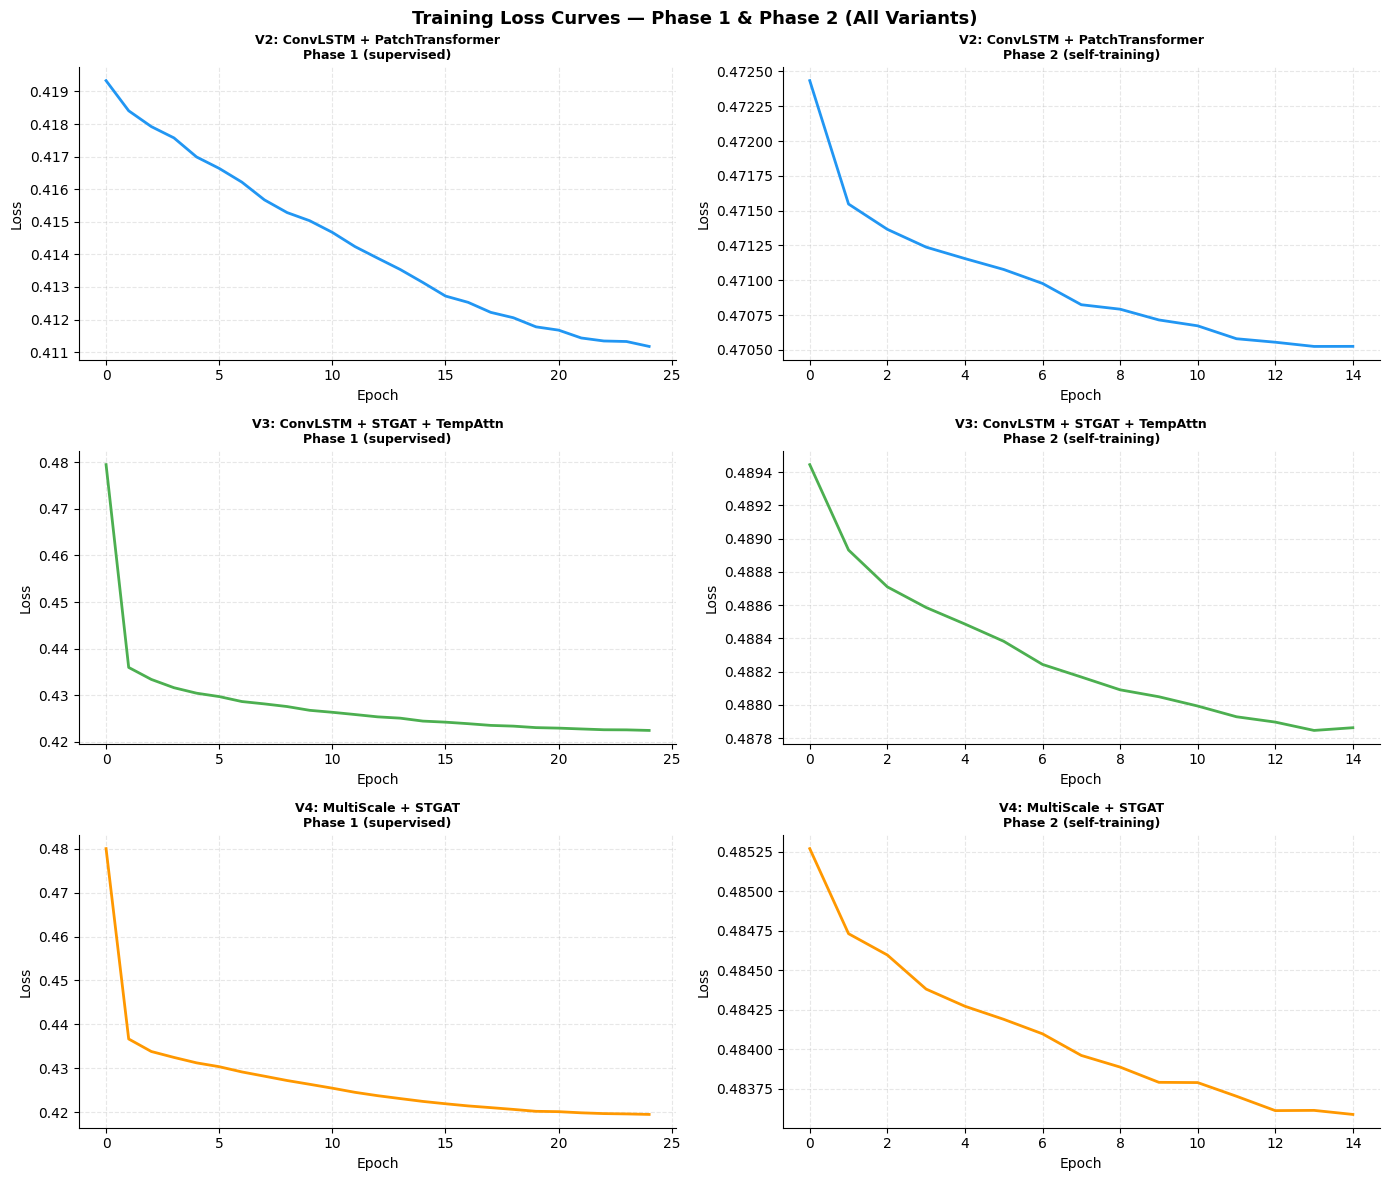

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Training Loss Curves — Phase 1 & Phase 2 (All Variants)',
             fontsize=13, fontweight='bold')

for row, (lp1, lp2, label, color) in enumerate([
    (v2_lp1, v2_lp2, 'V2: ConvLSTM + PatchTransformer', '#2196F3'),
    (v3_lp1, v3_lp2, 'V3: ConvLSTM + STGAT + TempAttn', '#4CAF50'),
    (v4_lp1, v4_lp2, 'V4: MultiScale + STGAT',           '#FF9800'),
]):
    for col, (losses, phase) in enumerate([(lp1,'Phase 1 (supervised)'),
                                            (lp2,'Phase 2 (self-training)')]):
        ax = axes[row][col]
        ax.plot(losses, color=color, linewidth=2)
        ax.set_title(f'{label}\n{phase}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.grid(alpha=0.3, linestyle='--')
        ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/chicago/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 STEP 15 — Grouped Bar Chart: All Metrics, All Variants

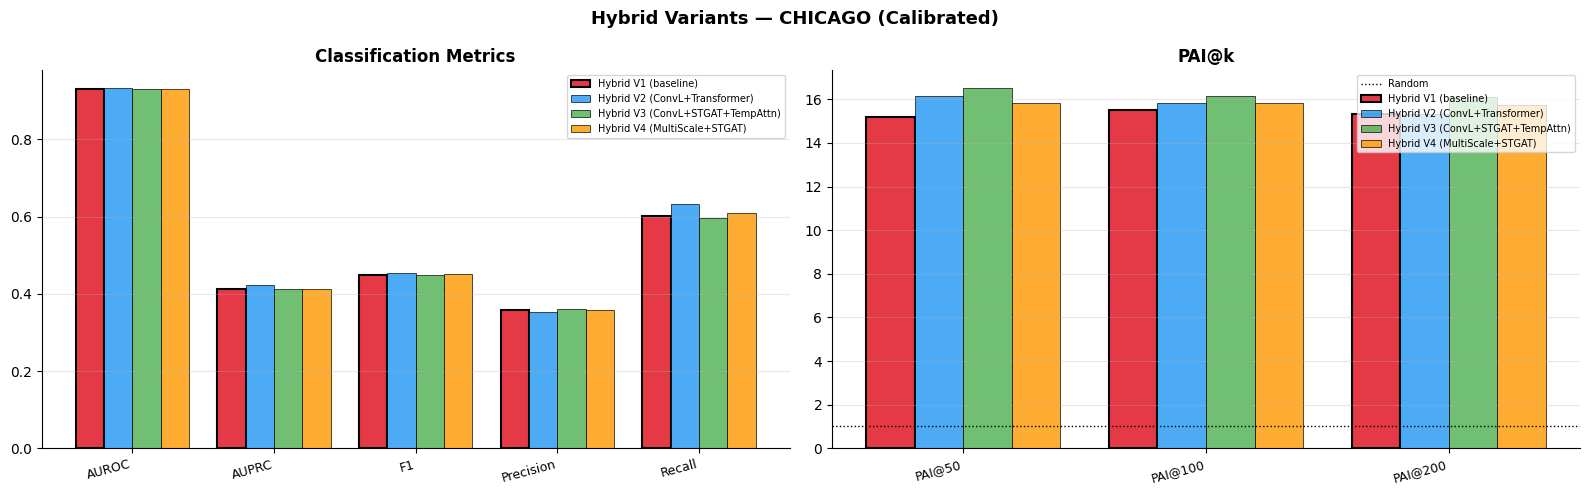

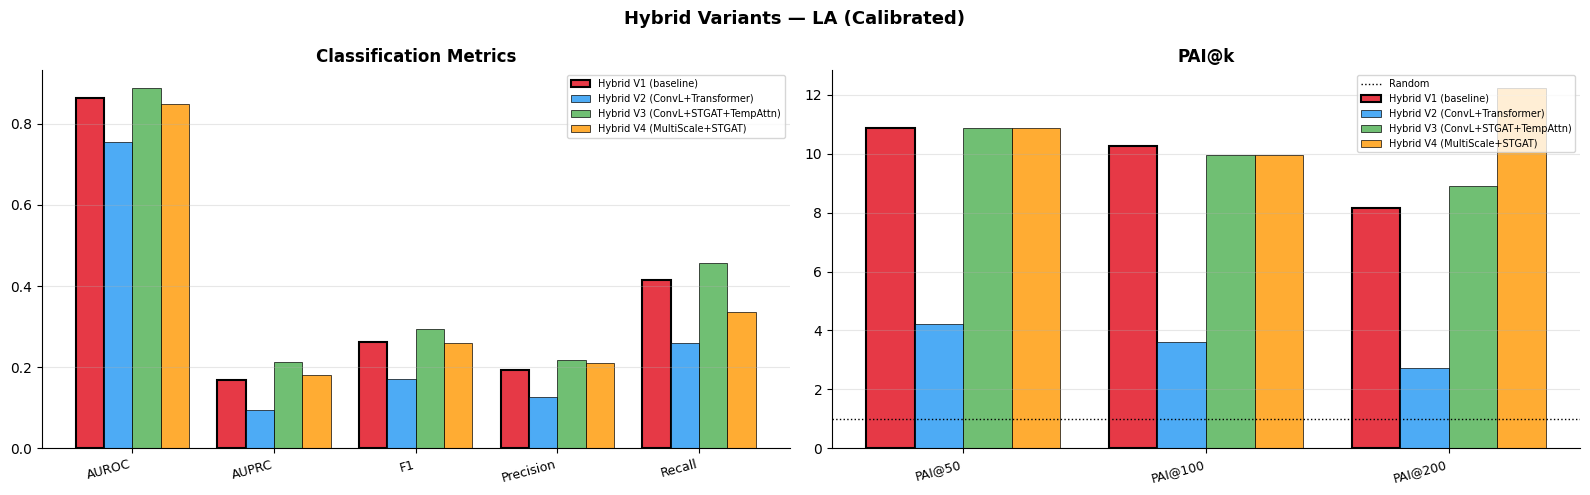

In [21]:
for city in ['chicago', 'la']:
    avail = [hk for hk in HYBRIDS if res[hk].get(city) is not None
             and res[hk][city] is not None]
    if not avail: continue

    bar_groups = [
        (['AUROC','AUPRC','F1','Precision','Recall'], 'Classification Metrics'),
        (['PAI@50','PAI@100','PAI@200'],               'PAI@k'),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Hybrid Variants — {city.upper()} (Calibrated)',
                 fontsize=13, fontweight='bold')

    for ax, (metrics, title) in zip(axes, bar_groups):
        mg = [m for m in metrics if res[avail[0]][city]['cal'].get(m) is not None]
        x_ = np.arange(len(mg)); n = len(avail); w = 0.8/n
        for i, hk in enumerate(avail):
            vals   = [res[hk][city]['cal'].get(m,0) for m in mg]
            offset = (i - n/2 + 0.5) * w
            bars   = ax.bar(x_+offset, vals, w,
                            label=HYBRIDS[hk][0], color=HYBRIDS[hk][1],
                            edgecolor='black', linewidth=1.5 if hk=='hybrid' else 0.6,
                            alpha=1.0 if hk=='hybrid' else 0.8)
        if 'PAI' in title:
            ax.axhline(1.0, color='black', linestyle=':', linewidth=1, label='Random')
        ax.set_xticks(x_); ax.set_xticklabels(mg, rotation=15, ha='right', fontsize=9)
        ax.set_title(title, fontweight='bold'); ax.legend(fontsize=7)
        ax.spines[['top','right']].set_visible(False); ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{city}/grouped_bars.png', dpi=150, bbox_inches='tight')
    plt.show()


## 📉 STEP 16 — ROC & PR Curves

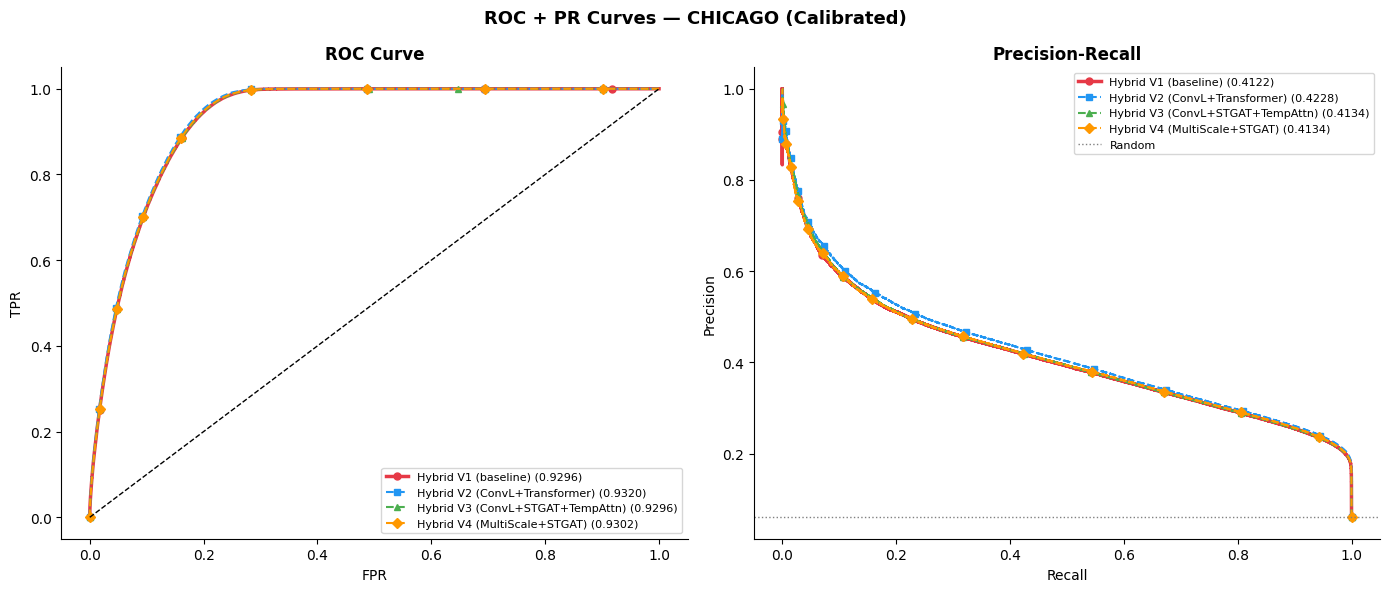

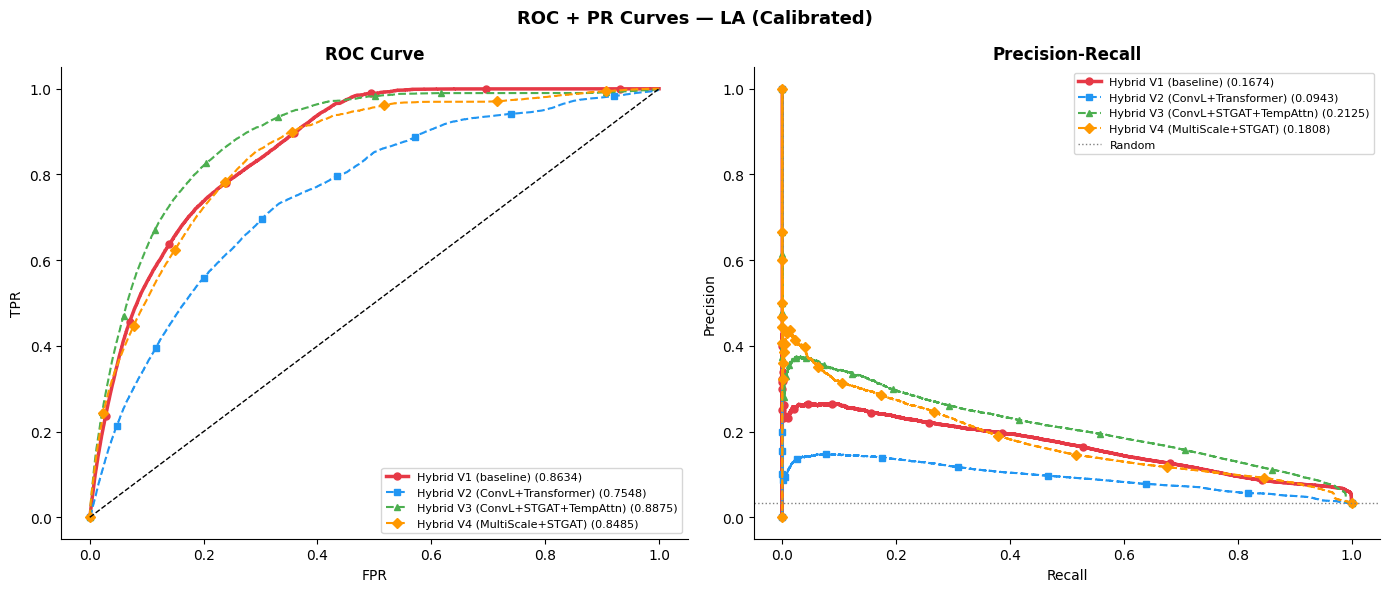

In [22]:
for city in ['chicago', 'la']:
    avail = [hk for hk in HYBRIDS if arts[hk].get(city) is not None]
    if not avail: continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'ROC + PR Curves — {city.upper()} (Calibrated)',
                 fontsize=13, fontweight='bold')

    for hk in avail:
        rp, cp, yt, mt = arts[hk][city]
        thr = mt.get('best_threshold', 0.5)
        lw = 2.5 if hk=='hybrid' else 1.5
        ls = '-'  if hk=='hybrid' else '--'
        c  = HYBRIDS[hk][1]; label = HYBRIDS[hk][0]
        mk = HYBRIDS[hk][2]

        fpr, tpr, _ = roc_curve(yt, cp)
        auc_v = roc_auc_score(yt, cp)
        axes[0].plot(fpr, tpr, color=c, lw=lw, ls=ls, marker=mk, markevery=0.15,
                     markersize=5, label=f'{label} ({auc_v:.4f})')

        prec, rec, _ = precision_recall_curve(yt, cp)
        ap = average_precision_score(yt, cp)
        axes[1].plot(rec, prec, color=c, lw=lw, ls=ls, marker=mk, markevery=0.15,
                     markersize=5, label=f'{label} ({ap:.4f})')

    axes[0].plot([0,1],[0,1],'k--',lw=1)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve', fontweight='bold')
    axes[0].legend(fontsize=8); axes[0].spines[['top','right']].set_visible(False)

    axes[1].axhline(float(yt.mean()), color='gray', ls=':', lw=1, label='Random')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall', fontweight='bold')
    axes[1].legend(fontsize=8); axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{city}/roc_pr.png', dpi=150, bbox_inches='tight')
    plt.show()


## 🌆 STEP 17 — Cross-City Transfer Gap

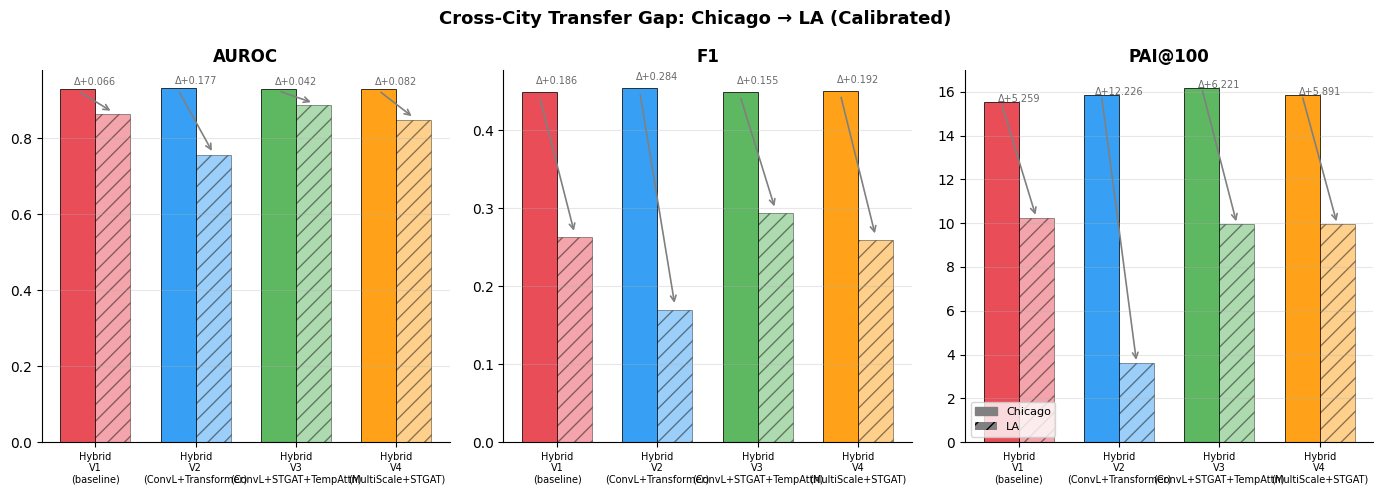

✅ Cross-city gap saved


In [23]:
both = [hk for hk in HYBRIDS if res[hk].get('chicago') and res[hk].get('la')
         and res[hk]['chicago'] and res[hk]['la']]

if not both:
    print('⚠️  No variants with both cities available')
else:
    gap_m = ['AUROC','F1','PAI@100']
    fig, axes = plt.subplots(1, len(gap_m), figsize=(14, 5))
    fig.suptitle('Cross-City Transfer Gap: Chicago → LA (Calibrated)',
                 fontsize=13, fontweight='bold')

    for ax, metric in zip(axes, gap_m):
        chi_v = [res[hk]['chicago']['cal'].get(metric,0) for hk in both]
        la_v  = [res[hk]['la']['cal'].get(metric,0)      for hk in both]
        x_    = np.arange(len(both)); w = 0.35
        ax.bar(x_-w/2, chi_v, w, color=[HYBRIDS[hk][1] for hk in both],
               edgecolor='black', lw=0.6, alpha=0.9, label='Chicago')
        ax.bar(x_+w/2, la_v,  w, color=[HYBRIDS[hk][1] for hk in both],
               edgecolor='black', lw=0.6, alpha=0.45, hatch='//', label='LA')
        for xi,(cv,lv) in enumerate(zip(chi_v,la_v)):
            if cv>lv:
                ax.annotate('', xy=(xi+w/2,lv+0.005), xytext=(xi-w/2,cv-0.005),
                            arrowprops=dict(arrowstyle='->',color='grey',lw=1.2))
            gap = cv - lv
            ax.text(xi, max(cv,lv)+0.01, f'Δ{gap:+.3f}', ha='center',
                    fontsize=7, color='dimgray')
        ax.set_xticks(x_)
        ax.set_xticklabels([HYBRIDS[hk][0].replace(' ','\n') for hk in both],
                           fontsize=7)
        ax.set_title(metric, fontweight='bold')
        ax.spines[['top','right']].set_visible(False); ax.grid(axis='y',alpha=0.3)

    solid = mpatches.Patch(color='gray', label='Chicago')
    hatch = mpatches.Patch(facecolor='gray', hatch='//', label='LA')
    axes[-1].legend(handles=[solid,hatch], fontsize=8)
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/crosscity/transfer_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Cross-city gap saved')


## 🏆 STEP 18 — Best Model Verdict

In [24]:
print('=' * 65)
print('  BEST HYBRID MODEL — VERDICT')
print('=' * 65)

# Score each model across Chicago+LA, calibrated, on 4 key metrics
score_metrics = ['AUROC','F1','PAI@100','PAI@200']
scores = {hk: 0 for hk in HYBRIDS}

for city in ['chicago','la']:
    for metric in score_metrics:
        avail = [hk for hk in HYBRIDS if res[hk].get(city) and res[hk][city]]
        if not avail: continue
        vals   = {hk: res[hk][city]['cal'].get(metric, 0) for hk in avail}
        ranked = sorted(vals, key=vals.get, reverse=True)
        # Award points: 1st=4, 2nd=3, 3rd=2, 4th=1
        for rank, hk in enumerate(ranked):
            scores[hk] += (len(ranked) - rank)

print('\nAggregated ranking score (higher = better across all cities + metrics):')
print('  (4pts for 1st, 3pts for 2nd, 2pts for 3rd, 1pt for 4th per metric per city)')
print()
ranked_models = sorted(scores, key=scores.get, reverse=True)
for rank, hk in enumerate(ranked_models, 1):
    medal = ['🥇','🥈','🥉','  '][min(rank-1,3)]
    print(f'  {medal}  Rank {rank}: {HYBRIDS[hk][0]:<38}  Score: {scores[hk]}')

winner = ranked_models[0]
print(f'\n✅ Best hybrid model: {HYBRIDS[winner][0]}')
print(f'   Weights : {MODEL_DIR}/{winner}.pt')
print(f'   Artefacts: {CAL_BASE}/{winner}/')

# ── Detailed winner vs V1 comparison ──────────────────────────────────────────
if winner != 'hybrid' and res[winner].get('chicago') and res['hybrid'].get('chicago'):
    print()
    print(f'  Δ {HYBRIDS[winner][0]} minus V1 Baseline (Chicago, Calibrated):')
    base = res['hybrid']['chicago']['cal']
    comp = res[winner]['chicago']['cal']
    for m in SHOW:
        delta = comp.get(m,0) - base.get(m,0)
        arrow = '↑' if delta>0 else ('↓' if delta<0 else '=')
        print(f'    {m:<12}: {arrow} {delta:+.4f}')

print()
print(f'📁 All outputs saved to {OUT_DIR}')
print('── Files generated ──')
for root, dirs, files in os.walk(OUT_DIR):
    rel = root.replace(OUT_DIR,'').lstrip('/')
    for fname in sorted(files):
        print(f'  {rel+"/"+fname if rel else fname}')


  BEST HYBRID MODEL — VERDICT

Aggregated ranking score (higher = better across all cities + metrics):
  (4pts for 1st, 3pts for 2nd, 2pts for 3rd, 1pt for 4th per metric per city)

  🥇  Rank 1: Hybrid V3 (ConvL+STGAT+TempAttn)        Score: 25
  🥈  Rank 2: Hybrid V4 (MultiScale+STGAT)            Score: 21
  🥉  Rank 3: Hybrid V1 (baseline)                    Score: 18
      Rank 4: Hybrid V2 (ConvL+Transformer)           Score: 16

✅ Best hybrid model: Hybrid V3 (ConvL+STGAT+TempAttn)
   Weights : /content/drive/MyDrive/CrimeHotspot/models/hybridv3.pt
   Artefacts: /content/drive/MyDrive/CrimeHotspot/outputs/calibration/hybridv3/

  Δ Hybrid V3 (ConvL+STGAT+TempAttn) minus V1 Baseline (Chicago, Calibrated):
    AUROC       : = +0.0000
    AUPRC       : ↑ +0.0012
    F1          : ↑ +0.0002
    Precision   : ↑ +0.0025
    Recall      : ↓ -0.0061
    PAI@50      : ↑ +1.3206
    PAI@100     : ↑ +0.6603
    PAI@200     : ↑ +0.7428

📁 All outputs saved to /content/drive/MyDrive/CrimeHotspot